In [ ]:
!pip install mne -q

In [ ]:
# Install MNE if not already installed (uncomment the line below if needed)
# !pip install mne -q

import mne
import matplotlib.pyplot as plt
import os

# Use the direct raw link provided by the user
data_link_source = 'https://raw.githubusercontent.com/MyProfile-projects/Wavelet.-P--R--and-T-peaks-detection/refs/heads/main/dataset_4_test/01_ГУСА.edf'

# Define the local path where the EDF file will be stored
# We will use the last part of the URL as the local filename.
# If it doesn't already have an .edf extension, we'll add one for MNE compatibility.
local_file_name_from_url = data_link_source.split('/')[-1]
if not local_file_name_from_url.lower().endswith('.edf'):
    local_file_name = local_file_name_from_url + '.edf'
else:
    local_file_name = local_file_name_from_url

edf_file_path = os.path.join('/tmp', local_file_name)

# Use !wget to download the file
print(f"Attempting to download {data_link_source} to {edf_file_path} using wget...")

# Delete existing file to ensure a fresh download, especially if previous attempts were corrupted
if os.path.exists(edf_file_path):
    print(f"Deleting existing file at {edf_file_path} to ensure fresh download.")
    os.remove(edf_file_path)

# Execute wget command silently (-q) and force output to specific filename (-O)
!wget -q -O {edf_file_path} {data_link_source}

# Verify if download was successful (check file existence and size)
MIN_EDF_SIZE_BYTES = 256 # A typical EDF header is 256 bytes

if os.path.exists(edf_file_path):
    file_size = os.path.getsize(edf_file_path)
    if file_size < MIN_EDF_SIZE_BYTES:
        print(f"Error: Downloaded file is too small ({file_size} bytes). This likely indicates the URL is incorrect (e.g., a 404 Not Found error) or the file is corrupted.")
        edf_file_path = None # Mark as invalid
    else:
        print(f"Download successful. File size: {file_size} bytes.")
else:
    print("Error: Download failed or file was not created by wget. Check the URL and network connection.")
    edf_file_path = None


# Initialize raw to None to prevent NameError if loading fails
raw = None

if edf_file_path:
    try:
        # Load the EDF file
        print(f"Loading EDF file from {edf_file_path} with MNE...")
        raw = mne.io.read_raw_edf(edf_file_path, preload=True)

        # Display basic information about the loaded data
        display(raw.info)

        # Filter out 'bad' channels if any
        initial_channel_count = len(raw.ch_names)
        raw.info['bads'] = [ch for ch in raw.ch_names if 'bad' in ch.lower()]
        if raw.info['bads']:
            print(f"Excluding bad channels: {raw.info['bads']}")
            raw.pick_channels([ch for ch in raw.ch_names if ch not in raw.info['bads']])

        print(f"Number of channels after filtering: {len(raw.ch_names)} (from {initial_channel_count})")

    except Exception as e:
        print(f"Error loading EDF file with MNE: {e}")
        print("The file might be genuinely corrupted or malformed, or MNE has trouble parsing it.")
        raw = None # Ensure raw is None if loading fails

# If raw is still None, indicate that processing cannot proceed
if raw is None:
    print("Cannot proceed with EDF data processing as 'raw' object is not defined.")

Attempting to download https://raw.githubusercontent.com/MyProfile-projects/Wavelet.-P--R--and-T-peaks-detection/refs/heads/main/dataset_4_test/01_ГУСА.edf to /tmp/01_ГУСА.edf using wget...
Deleting existing file at /tmp/01_ГУСА.edf to ensure fresh download.
Download successful. File size: 3997024 bytes.
Loading EDF file from /tmp/01_ГУСА.edf with MNE...
Extracting EDF parameters from /tmp/01_ГУСА.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 665999  =      0.000 ...  3329.995 secs...


<Info | 8 non-empty values
 bads: []
 ch_names: ECG V2-Ref, ECG V5-Ref, ECG avF-Ref
 chs: 3 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 100.0 Hz
 meas_date: 2017-11-14 11:30:20 UTC
 nchan: 3
 projs: []
 sfreq: 200.0 Hz
 subject_info: <subject_info | his_id: >
>

Number of channels after filtering: 3 (from 3)


Found ECG channels: ['ECG V2-Ref', 'ECG V5-Ref', 'ECG avF-Ref']
Using matplotlib as 2D backend.


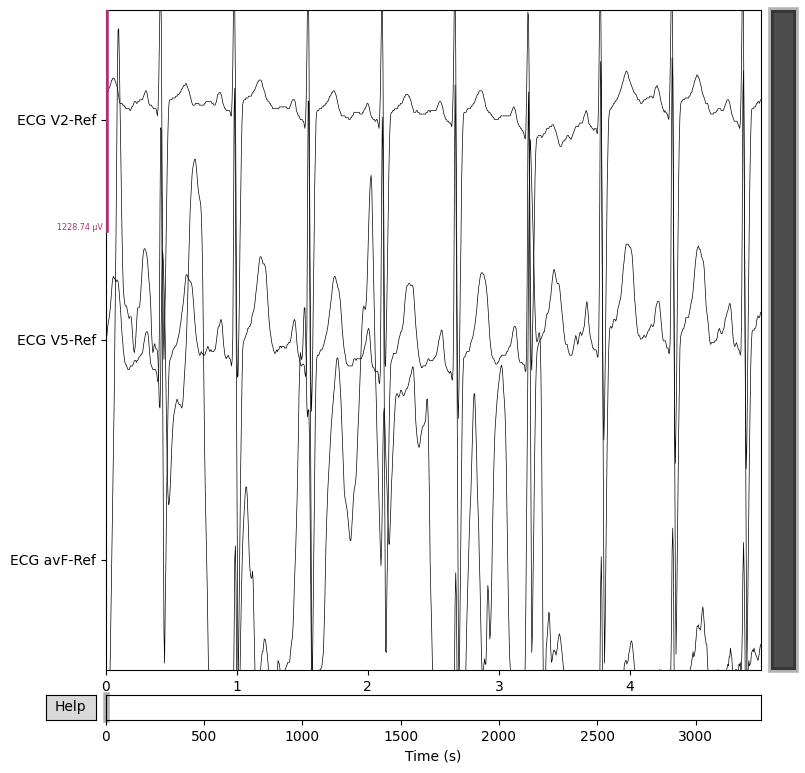

<Figure size 640x480 with 0 Axes>

In [ ]:
# Find ECG channels (assuming channels containing 'ECG' in their names)
ecg_channels = [ch for ch in raw.ch_names if 'ECG' in ch.upper()]

if ecg_channels:
    print(f"Found ECG channels: {ecg_channels}")
    # Plot ECG channels
    # We'll plot a segment of the data to make it manageable
    # Adjust duration and n_channels as needed
    raw.plot(duration=5, start=0, n_channels=len(ecg_channels), scalings='auto', picks=ecg_channels, show_scrollbars=True)
    plt.tight_layout()
    plt.show()
else:
    print("No ECG channels found in the file. Plotting all channels for a quick overview.")
    # If no ECG channels are explicitly named, plot all channels
    raw.plot(duration=5, start=0, n_channels=5, scalings='auto', show_scrollbars=True)
    plt.tight_layout()
    plt.show()

In [ ]:
#0. data that we work with
import numpy as np
# Get the 'ECG V2-Ref' channel data
# Assuming raw, sfreq, and ecg_channels are available from previous cells

# Find the index of 'ECG V2-Ref' in raw.ch_names
try:
    ecg_v2_ref_idx = raw.ch_names.index('ECG V2-Ref')
except ValueError:
    print("Error: 'ECG V2-Ref' channel not found in the raw data.")
    raise

ec_v2_ref_data = raw.get_data(picks='ECG V2-Ref').flatten() * 1e6 # Convert to microvolts
sfreq = raw.info['sfreq']

# Define the time window
start_time_s = 0
duration_s = 5
end_time_s = start_time_s + duration_s

# Convert time window to sample indices
start_sample = int(start_time_s * sfreq)
end_sample = int(end_time_s * sfreq)

# Ensure the window is within the bounds of the data
start_sample = max(0, start_sample)
end_sample = min(len(ec_v2_ref_data), end_sample)

# Extract the ECG data for the specified window
windowed_ecg_data = ec_v2_ref_data[start_sample:end_sample]
time_axis_windowed = np.arange(start_sample, end_sample) / sfreq

print(f"Processing 'ECG V2-Ref' channel from {start_time_s}s to {end_time_s}s.")

Processing 'ECG V2-Ref' channel from 0s to 5s.


In [ ]:
# 1. Baseline - Neurophysiological Signal Processing (NeuroKit2)
!pip install neurokit2 -q

In [ ]:
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np

Detected 9 R-peaks using NeuroKit2.
Detected 9 P-peaks using NeuroKit2.
Detected 8 T-peaks using NeuroKit2.


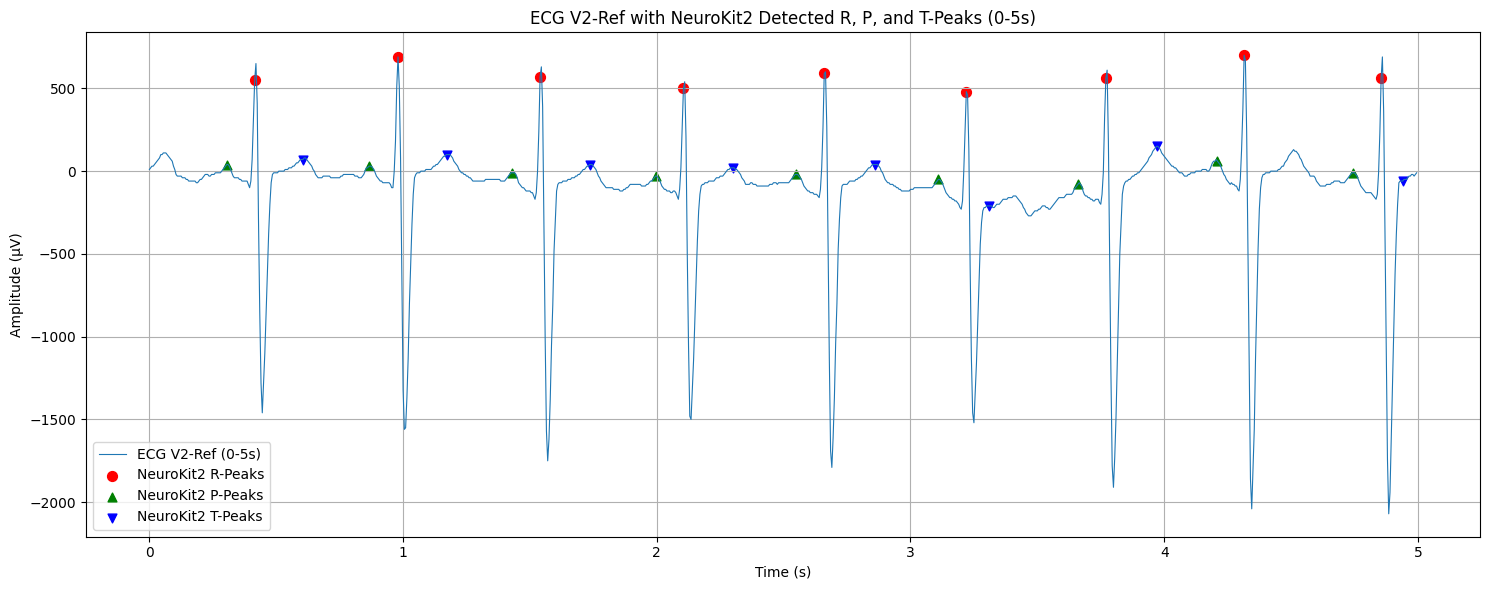

In [ ]:
# Process the ECG signal to find R, P, and T-peaks using NeuroKit2
# NeuroKit expects samples, so we pass the windowed data and its sampling frequency
processed_data, events = nk.ecg_process(windowed_ecg_data, sampling_rate=sfreq, method='neurokit')

# Get R-peak locations in samples relative to the start of the windowed_ecg_data
r_peaks_local_indices = events['ECG_R_Peaks']

# Get P-peak and T-peak locations, ensuring they are NumPy arrays
# Filter out NaN values and convert to integers for indexing
p_peaks_local_indices = np.array(events.get('ECG_P_Peaks', []))
p_peaks_local_indices_valid = p_peaks_local_indices[~np.isnan(p_peaks_local_indices)].astype(int)

t_peaks_local_indices = np.array(events.get('ECG_T_Peaks', []))
t_peaks_local_indices_valid = t_peaks_local_indices[~np.isnan(t_peaks_local_indices)].astype(int)


# Convert local peak indices to global time (seconds) for plotting
r_peaks_global_time = (r_peaks_local_indices + start_sample) / sfreq
p_peaks_global_time = (p_peaks_local_indices_valid + start_sample) / sfreq
t_peaks_global_time = (t_peaks_local_indices_valid + start_sample) / sfreq

print(f"Detected {len(r_peaks_local_indices)} R-peaks using NeuroKit2.")
print(f"Detected {len(p_peaks_local_indices_valid)} P-peaks using NeuroKit2.")
print(f"Detected {len(t_peaks_local_indices_valid)} T-peaks using NeuroKit2.")

# Plot the windowed ECG signal and mark the R, P, and T-peaks
plt.figure(figsize=(15, 6))
plt.plot(time_axis_windowed, windowed_ecg_data, label='ECG V2-Ref (0-5s)', linewidth=0.8)

# Plot R-peaks
plt.scatter(r_peaks_global_time, windowed_ecg_data[r_peaks_local_indices], color='red', s=50, marker='o', label='NeuroKit2 R-Peaks')

# Plot P-peaks
if len(p_peaks_local_indices_valid) > 0:
    plt.scatter(p_peaks_global_time, windowed_ecg_data[p_peaks_local_indices_valid], color='green', s=40, marker='^', label='NeuroKit2 P-Peaks')

# Plot T-peaks
if len(t_peaks_local_indices_valid) > 0:
    plt.scatter(t_peaks_global_time, windowed_ecg_data[t_peaks_local_indices_valid], color='blue', s=40, marker='v', label='NeuroKit2 T-Peaks')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('ECG V2-Ref with NeuroKit2 Detected R, P, and T-Peaks (0-5s)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
windowed_ecg_data[r_peaks_local_indices]

array([550., 690., 570., 500., 590., 480., 560., 700., 560.])

In [ ]:
windowed_ecg_data[p_peaks_local_indices_valid]

array([ 40.,  30., -10., -30., -20., -50., -80.,  60., -10.])

In [ ]:
windowed_ecg_data[t_peaks_local_indices_valid]

array([  70.,  100.,   40.,   20.,   40., -210.,  150.,  -60.])

In [ ]:
r_peaks_global_time

array([0.415, 0.98 , 1.54 , 2.105, 2.66 , 3.22 , 3.77 , 4.315, 4.855])

In [ ]:
p_peaks_global_time

array([0.305, 0.865, 1.43 , 1.995, 2.55 , 3.11 , 3.66 , 4.21 , 4.745])

In [ ]:
t_peaks_global_time

array([0.605, 1.175, 1.735, 2.3  , 2.86 , 3.31 , 3.97 , 4.94 ])

In [ ]:
#2. Wavelet Transform and Modified Shannon Energy Envelope - 2017 year method https://pmc.ncbi.nlm.nih.gov/articles/PMC5516746/pdf/JHE2017-4901017.pdf$0

In [ ]:
# This cell defines the ecg_graph_pipeline module functions to resolve import errors.
# These are placeholder/simplified implementations for demonstration purposes.
import numpy as np
from scipy.signal import find_peaks

def filter_qrs(ecg_signal, r_peaks_indices, sfreq):
    """Simplified QRS filtering by linear interpolation.
    This function aims to remove the QRS complex by interpolating
    the signal around detected R-peaks. This is a basic implementation.
    """
    qrs_filtered_ecg = np.copy(ecg_signal)
    qrs_window_samples = int(0.080 * sfreq) # e.g., +/- 80ms around R-peak

    for r_idx in r_peaks_indices:
        start_interp = max(0, r_idx - qrs_window_samples)
        end_interp = min(len(ecg_signal) - 1, r_idx + qrs_window_samples)

        if start_interp >= end_interp:
            continue # Not enough space to interpolate

        # Get values at the edges of the interpolation window
        val_start = ecg_signal[start_interp]
        val_end = ecg_signal[end_interp]

        # Perform linear interpolation
        if start_interp < end_interp:
            interp_values = np.linspace(val_start, val_end, num=(end_interp - start_interp + 1))
            qrs_filtered_ecg[start_interp:end_interp+1] = interp_values

    return qrs_filtered_ecg

def detect_pt_peaks(qrs_filtered_ecg, r_peaks_indices, sfreq):
    """Simplified P and T peak detection using local extrema in filtered ECG.
    This function searches for P-waves before R-peaks and T-waves after R-peaks
    in the QRS-filtered ECG signal. This is a basic implementation.
    """
    p_peaks = []
    t_peaks = []

    # Define search windows based on sampling frequency
    # P-wave search: e.g., 250ms before R-peak to 80ms before R-peak
    p_search_start_rel = int(0.250 * sfreq) # 250 ms before R-peak
    p_search_end_rel = int(0.080 * sfreq)  # 80 ms before R-peak (end of QRS-interpolation)

    # T-wave search: e.g., 80ms after R-peak to 300ms after R-peak
    t_search_start_rel = int(0.080 * sfreq) # 80 ms after R-peak (start of QRS-interpolation)
    t_search_end_rel = int(0.300 * sfreq)  # 300 ms after R-peak

    for r_idx in r_peaks_indices:
        # Search for P-wave before R-peak
        p_window_start = max(0, r_idx - p_search_start_rel)
        p_window_end = min(len(qrs_filtered_ecg), r_idx - p_search_end_rel)

        if p_window_start < p_window_end:
            p_segment = qrs_filtered_ecg[p_window_start:p_window_end]
            if len(p_segment) > 0:
                # Find the maximum (positive P-wave) or minimum (negative P-wave) in the segment
                # For simplicity, let's find local peaks (can be positive or negative)
                # A more advanced approach would use morphology or specific thresholds.
                peaks_in_segment_pos, _ = find_peaks(p_segment, height=0)
                peaks_in_segment_neg, _ = find_peaks(-p_segment, height=0) # Find valleys

                peak_candidates = []
                if len(peaks_in_segment_pos) > 0:
                    peak_candidates.append(p_window_start + peaks_in_segment_pos[np.argmax(p_segment[peaks_in_segment_pos])])
                if len(peaks_in_segment_neg) > 0:
                    peak_candidates.append(p_window_start + peaks_in_segment_neg[np.argmin(p_segment[peaks_in_segment_neg])])

                if peak_candidates:
                    # Take the peak with the largest absolute amplitude
                    best_p_idx = peak_candidates[np.argmax(np.abs([qrs_filtered_ecg[idx] for idx in peak_candidates]))]
                    p_peaks.append(best_p_idx)

        # Search for T-wave after R-peak
        t_window_start = max(0, r_idx + t_search_start_rel)
        t_window_end = min(len(qrs_filtered_ecg), r_idx + t_search_end_rel)

        if t_window_start < t_window_end:
            t_segment = qrs_filtered_ecg[t_window_start:t_window_end]
            if len(t_segment) > 0:
                peaks_in_segment_pos, _ = find_peaks(t_segment, height=0)
                peaks_in_segment_neg, _ = find_peaks(-t_segment, height=0) # Find valleys

                peak_candidates = []
                if len(peaks_in_segment_pos) > 0:
                    peak_candidates.append(t_window_start + peaks_in_segment_pos[np.argmax(t_segment[peaks_in_segment_pos])])
                if len(peaks_in_segment_neg) > 0:
                    peak_candidates.append(t_window_start + peaks_in_segment_neg[np.argmin(t_segment[peaks_in_segment_neg])])

                if peak_candidates:
                    best_t_idx = peak_candidates[np.argmax(np.abs([qrs_filtered_ecg[idx] for idx in peak_candidates]))]
                    t_peaks.append(best_t_idx)

    return np.array(p_peaks, dtype=float), np.array(t_peaks, dtype=float)


Starting WTSEE R-peak detection for: ECG V2-Ref (0-5s window)
Processing preloaded signal: ECG V2-Ref (0-5s window) at 200.0 Hz
Original signal length for ECG V2-Ref (0-5s window): 1000
Denoised signal (EF) length: 1000
Initial peaks found in PSE (downsampled space) for ECG V2-Ref (0-5s window): 17
Refined peaks (in EF signal space) for ECG V2-Ref (0-5s window): 17
Final validated peaks for ECG V2-Ref (0-5s window): 11
Detected 11 R-peaks using WTSEE for ECG V2-Ref (0-5s window).
Detected 10 P-peaks using ecg_graph_pipeline for ECG V2-Ref (0-5s window).
Detected 11 T-peaks using ecg_graph_pipeline for ECG V2-Ref (0-5s window).


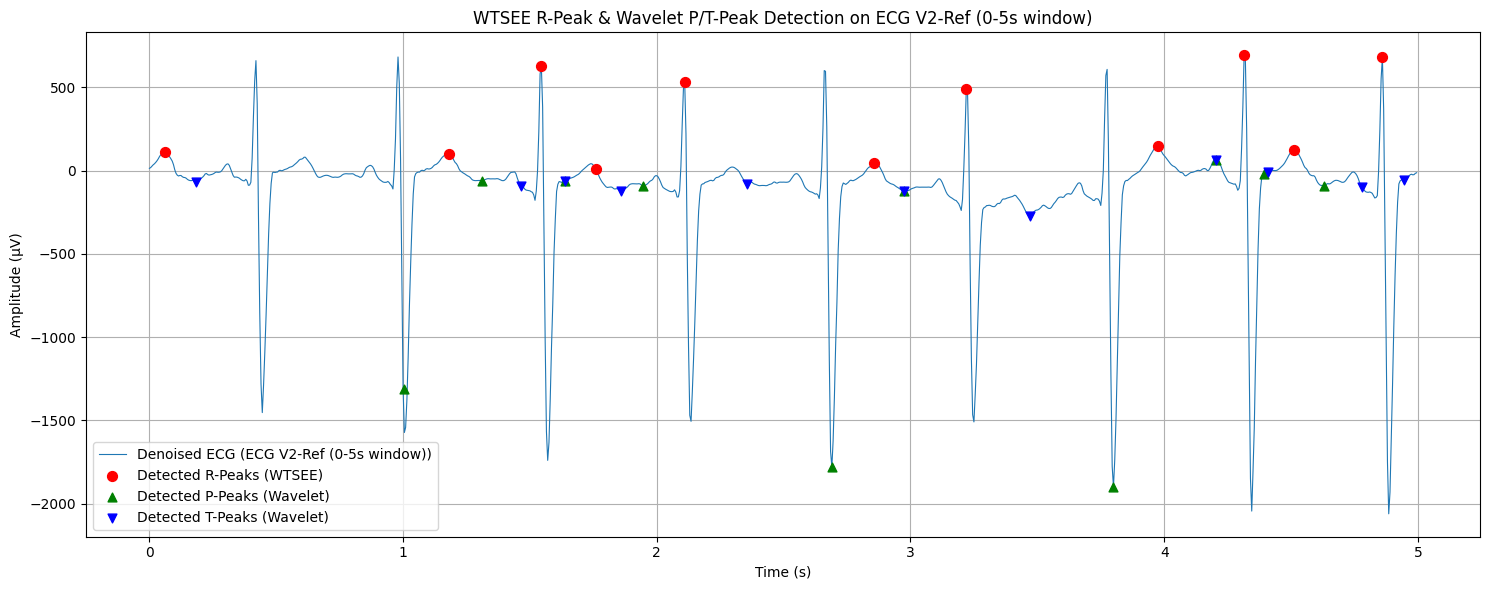

In [ ]:
# --- Install Required Libraries ---
# Run this cell only once per session if libraries are not already installed
!pip install pyEDFlib PyWavelets -q

# --- Import Libraries ---
import numpy as np
import pyedflib # Library to read EDF files
import pywt     # Library for wavelet transforms
from scipy import signal # For moving average filtering
import matplotlib.pyplot as plt # For plotting

# Import functions for P and T peak detection from the ecg_graph_pipeline module
# Assuming ecg_graph_pipeline is already available in the environment as confirmed by prior cell executions.
# The functions filter_qrs and detect_pt_peaks are now defined in cell 1d4bcb9e
# Therefore, we directly use them instead of importing from a non-existent module.
# from ecg_graph_pipeline import filter_qrs, detect_pt_peaks # This line was causing the error

# --- Helper Functions ---

def calculate_threshold(coeffs):
    """Calculates universal threshold for soft thresholding."""
    sigma = np.median(np.abs(coeffs)) / 0.6745
    N = len(coeffs)
    return sigma * np.sqrt(2 * np.log(N))

def apply_soft_threshold(coeffs, threshold):
    """Applies soft thresholding."""
    return np.sign(coeffs) * np.maximum(np.abs(coeffs) - threshold, 0)

def find_peaks_in_pse(pse_signal, height=None, distance=1):
    """
    Finds peaks in the Peak Energy Envelope (PSE) signal.
    Uses scipy.signal.find_peaks. No amplitude threshold needed based on the paper.
    """
    peaks, _ = signal.find_peaks(pse_signal, height=height, distance=distance)
    return peaks

def update_r_peaks(r_candidates, fs, alpha=0.5, beta=1.5, gamma=0.5):
    """
    Validates and updates R peaks based on R-R intervals.
    """
    if len(r_candidates) < 2:
        return r_candidates

    # Calculate initial R-R intervals
    rr_intervals = np.diff(r_candidates)

    # Estimate average R-R interval (using median might be more robust)
    avg_rr_samples = int(np.median(rr_intervals))

    # Define thresholds based on average interval
    theta_delta_1 = int(alpha * avg_rr_samples)
    theta_delta_2 = int(beta * avg_rr_samples)
    gamma_search = int(gamma * avg_rr_samples)

    simple_final_peaks = []
    for i in range(len(r_candidates)):
        current_peak = r_candidates[i]
        prev_interval = rr_intervals[i-1] if i > 0 else float('inf')
        curr_interval = rr_intervals[i] if i < len(rr_intervals) else float('inf')

        if theta_delta_1 <= prev_interval <= theta_delta_2 and theta_delta_1 <= curr_interval <= theta_delta_2:
             simple_final_peaks.append(current_peak)
        elif i == 0 and curr_interval <= theta_delta_2: # First peak case
             simple_final_peaks.append(current_peak)
        elif i == len(r_candidates)-1 and prev_interval <= theta_delta_2: # Last peak case
             simple_final_peaks.append(current_peak)
        # Note: This simple rule might not perfectly match the paper's complex logic,
        # especially for missed peak insertion, but covers basic validation.

    # Return the simpler version for now. The complex logic needs original signal access for missed peaks.
    return simple_final_peaks

# --- Main R-Peak Detection Function (WTSEE Algorithm) ---
def detect_r_peaks_wf(edf_file_path=None, ecg_channel_index=0, fs_expected=None, preloaded_signal=None, preloaded_fs=None, channel_name_for_logging=None):
    """
    Detects R peaks in an ECG signal using the WTSEE algorithm, either from an EDF file
    or from a preloaded signal.

    Args:
        edf_file_path (str, optional): Path to the EDF file. Required if preloaded_signal is None.
        ecg_channel_index (int): Index of the ECG channel in the file (default 0). Used if reading from EDF.
        fs_expected (float, optional): Expected sampling frequency. Used if not available in file header or if preloaded.
        preloaded_signal (np.ndarray, optional): Preloaded ECG signal array. If provided, edf_file_path is ignored.
        preloaded_fs (float, optional): Sampling frequency of the preloaded signal. Required if preloaded_signal is provided.
        channel_name_for_logging (str, optional): Name of the channel being processed, for logging.

    Returns:
        tuple: (timestamps_of_detected_peaks, denoised_ecg_signal, sampling_frequency)
               Returns (None, None, None) if an error occurs.
    """
    ei_signal = None
    fs = None
    current_channel_name = channel_name_for_logging if channel_name_for_logging else "Unknown Channel"

    try:
        if preloaded_signal is not None and preloaded_fs is not None:
            ei_signal = preloaded_signal.astype(float)
            fs = preloaded_fs
            print(f"Processing preloaded signal: {current_channel_name} at {fs} Hz")
        elif edf_file_path:
            # 1. Read EDF file
            f = pyedflib.EdfReader(edf_file_path)
            n_channels = f.signals_in_file
            print(f"Number of signals in file: {n_channels}")

            if ecg_channel_index >= n_channels:
                raise ValueError(f"Channel index {ecg_channel_index} exceeds number of signals ({n_channels})")

            # Get signal info and data
            signal_labels = f.getSignalLabels()
            current_channel_name = signal_labels[ecg_channel_index] # Update channel name from EDF
            print(f"Signal labels: {signal_labels}")

            ecg_signal_from_edf = f.readSignal(ecg_channel_index)
            fs_from_file = f.getSampleFrequency(ecg_channel_index) # Attempt to get from file
            fs = fs_expected if fs_expected is not None else fs_from_file

            if fs is None:
                print("Warning: Sampling frequency not found in file and not provided. Assuming 360 Hz.")
                fs = 360.0 # Default assumption based on paper's validation

            print(f"Using sampling frequency: {fs} Hz for channel: {current_channel_name}")
            f.close()
            ei_signal = ecg_signal_from_edf.astype(float)
        else:
            print("Error: Either edf_file_path or preloaded_signal/preloaded_fs must be provided.")
            return None, None, None

        n_original = len(ei_signal)
        print(f"Original signal length for {current_channel_name}: {n_original}")

        # --- Step 1: Wavelet Transform (WT) for Denoising and Downsampling ---
        # Paper uses sym5, level 1 decomposition, soft thresholding on details, reconstruct level 1
        wavelet_name = 'sym5'

        # Perform 1-level DWT
        cA1, cD1 = pywt.dwt(ei_signal, wavelet_name, mode='symmetric') # 'symmetric' padding often used

        # Calculate threshold for detail coefficients
        threshold = calculate_threshold(cD1)

        # Apply soft thresholding to detail coefficients
        cD1_thresh = apply_soft_threshold(cD1, threshold)

        # Reconstruct the level 1 signal (EF) using approx and thresh. details
        ef_signal = pywt.idwt(cA1, cD1_thresh, wavelet_name, mode='symmetric')

        # The reconstructed signal 'ef_signal' might be slightly longer than cA1/cD1
        # The 'down-sampling' mentioned might be conceptual (reducing detail via thresholding)
        # or refer to using the approximation coefficients directly, but the paper says reconstruct.
        # We'll use ef_signal for subsequent steps.
        fs_ef = fs # Sampling frequency remains the same for the reconstructed signal

        print(f"Denoised signal (EF) length: {len(ef_signal)}")

        # --- Step 2: Shannon Energy Envelope (SEE) Calculation ---
        # 2.1: First-order differentiation of EF
        d_signal = np.diff(ef_signal, append=ef_signal[-1]) # Append last value to maintain length
        # d_signal = np.gradient(ef_signal) # Alternative gradient calculation

        # 2.2: Amplitude normalization
        max_abs_d = np.max(np.abs(d_signal))
        if max_abs_d != 0:
            dn_signal = d_signal / max_abs_d
        else:
            print("Warning: Max absolute value of differentiated signal is zero. Cannot normalize.")
            return [], ef_signal, fs_ef

        # 2.3: Modified Shannon Energy (SE)
        # Avoid log(0) by adding a small epsilon or masking
        epsilon = 1e-10
        dn_sq = dn_signal**2
        log_term = np.log(dn_sq + epsilon)
        se_signal = -dn_sq * log_term

        # 2.4: Moving Average Filter for SEE (Window length 33 samples)
        window_length_see = 33
        if len(se_signal) >= window_length_see:
             ss_signal = np.convolve(se_signal, np.ones(window_length_see)/window_length_see, mode='same')
        else:
             print(f"Warning: Signal length ({len(se_signal)}) is shorter than SEE window ({window_length_see}). Cannot apply filter.")
             return [], ef_signal, fs_ef


        # --- Step 3: Peak Energy Envelope (PEE) Calculation ---
        # 3.1: First-order differentiation of SEE (SS)
        ds_signal = np.diff(ss_signal, append=ss_signal[-1])
        # ds_signal = np.gradient(ss_signal) # Alternative

        # 3.2: Amplitude normalization
        max_abs_ds = np.max(np.abs(ds_signal))
        if max_abs_ds != 0:
            dn_ds_signal = ds_signal / max_abs_ds
        else:
            print("Warning: Max absolute value of differentiated SEE is zero. Cannot normalize.")
            return [], ef_signal, fs_ef

        # 3.3: Squaring operation (PE)
        pe_signal = dn_ds_signal**2

        # 3.4: Moving Average Filter for PEE (Window length 43 samples)
        window_length_pee = 43
        if len(pe_signal) >= window_length_pee:
             ps_signal = np.convolve(pe_signal, np.ones(window_length_pee)/window_length_pee, mode='same')
        else:
             print(f"Warning: Signal length ({len(pe_signal)}) is shorter than PEE window ({window_length_pee}). Cannot apply filter.")
             return [], ef_signal, fs_ef


        # --- Step 4: Peak Detection from PSE (PS) ---
        # 4.1: Find peaks in the PSE (PS) signal
        # The paper suggests no amplitude threshold is needed as peak location matters.
        # scipy find_peaks might need a minimal distance.
        # The paper says "rising peaks" correspond to R peaks. find_peaks finds local maxima.
        # Let's find peaks with a minimal distance related to expected heart rate (e.g., 200ms min = 0.2 * fs_ef samples)
        min_distance_samples = max(1, int(0.2 * fs_ef))
        initial_peak_indices_t2 = find_peaks_in_pse(ps_signal, distance=min_distance_samples)

        print(f"Initial peaks found in PSE (downsampled space) for {current_channel_name}: {len(initial_peak_indices_t2)}")


        # --- Step 5: Refine Peak Locations (Adjust from input ECG EF) ---
        # 5.1: Refine peaks by finding max amplitude in original EF signal
        # Search within +/- 25 samples of the location found in PS around the initial peak index.
        # Note: The initial peak index 'idx_t2' is in the downsampled/reconstructed 'ef_signal' space.
        refined_peak_indices_t1 = []
        search_window_half = 25
        for idx_t2 in initial_peak_indices_t2:
            start_search = max(0, idx_t2 - search_window_half)
            end_search = min(len(ef_signal), idx_t2 + search_window_half + 1) # +1 for slice inclusion
            if end_search > start_search:
                segment = ef_signal[start_search:end_search]
                local_max_idx_in_segment = np.argmax(segment)
                # Convert back to global index in EF signal
                global_idx = start_search + local_max_idx_in_segment
                refined_peak_indices_t1.append(global_idx)

        # Remove duplicates if any arise from overlapping searches
        refined_peak_indices_t1 = sorted(list(set(refined_peak_indices_t1)))
        print(f"Refined peaks (in EF signal space) for {current_channel_name}: {len(refined_peak_indices_t1)}")


        # --- Step 6: R Peak Update (Validation based on R-R intervals) ---
        # 6.1: Validate and update the refined peak list
        # Pass the sampling frequency to the update function
        final_peak_indices = update_r_peaks(refined_peak_indices_t1, fs_ef)
        print(f"Final validated peaks for {current_channel_name}: {len(final_peak_indices)}")

        # Convert final peak indices to timestamps relative to the start of the signal
        peak_timestamps = np.array(final_peak_indices) / fs_ef

        return peak_timestamps, ef_signal, fs_ef

    except FileNotFoundError:
        print(f"Error: File '{edf_file_path}' not found.")
        return None, None, None
    except Exception as e:
        print(f"An error occurred during processing for {current_channel_name}: {e}")
        return None, None, None


# --- Example Usage with previously extracted windowed ECG data ---
# We will use the 'windowed_ecg_data' and 'sfreq' from previous cells (tSZZ_4s6MCNv).
# The 'detect_r_peaks_wf' function has been modified to accept preloaded signals.

# Ensure windowed_ecg_data and sfreq are available (from cell tSZZ_4s6MCNv)
if 'windowed_ecg_data' not in locals() or 'sfreq' not in locals():
    print("Error: 'windowed_ecg_data' or 'sfreq' not found. Please run cell tSZZ_4s6MCNv first.")
else:
    processed_channel_name = 'ECG V2-Ref (0-5s window)' # Name for this specific processed signal

    print(f"\nStarting WTSEE R-peak detection for: {processed_channel_name}")
    # Call the modified detect_r_peaks_wf with the preloaded windowed_ecg_data
    peaks_ts, denoised_ecg_signal, fs_out = detect_r_peaks_wf(
        preloaded_signal=windowed_ecg_data,
        preloaded_fs=sfreq, # sfreq is available from tSZZ_4s6MCNv
        channel_name_for_logging=processed_channel_name
    )

    p_peaks_ts = np.array([])
    t_peaks_ts = np.array([])

    all_channel_results = {} # Reset to store only the new result
    if peaks_ts is not None and len(peaks_ts) > 0:
        print(f"Detected {len(peaks_ts)} R-peaks using WTSEE for {processed_channel_name}.")

        # Convert R-peak timestamps to sample indices for P and T detection functions
        r_idx_for_pt = (peaks_ts * fs_out).astype(int)

        # Filter out QRS complexes from the denoised signal
        # The filter_qrs function expects indices relative to its input signal.
        # Since ef_signal (denoised_ecg_signal) is the output from WTSEE, we use it here.
        qrs_filtered_ecg = filter_qrs(denoised_ecg_signal, r_idx_for_pt, fs_out)

        # Detect P and T peaks using the ecg_graph_pipeline functions
        # These functions expect the QRS-filtered signal and R-peak indices
        p_idx, t_idx = detect_pt_peaks(qrs_filtered_ecg, r_idx_for_pt, fs_out)

        # Convert P and T peak indices to timestamps
        p_peaks_ts = p_idx / fs_out
        t_peaks_ts = t_idx / fs_out

        print(f"Detected {len(p_peaks_ts)} P-peaks using ecg_graph_pipeline for {processed_channel_name}.")
        print(f"Detected {len(t_peaks_ts)} T-peaks using ecg_graph_pipeline for {processed_channel_name}.")

        all_channel_results[processed_channel_name] = {
            'r_peaks_ts': peaks_ts,
            'p_peaks_ts': p_peaks_ts,
            't_peaks_ts': t_peaks_ts,
            'ecg_sig': denoised_ecg_signal,
            'fs_out': fs_out
        }
    else:
        print("No R-peaks were detected for {processed_channel_name} or an error occurred. Skipping P and T detection.")


    # --- Plotting the single processed channel with R, P, and T peaks ---
    if all_channel_results:
        fig, ax = plt.subplots(1, 1, figsize=(15, 6))

        channel_name_plot = list(all_channel_results.keys())[0]
        results = all_channel_results[channel_name_plot]

        r_peaks_ts = results['r_peaks_ts']
        p_peaks_ts = results['p_peaks_ts']
        t_peaks_ts = results['t_peaks_ts']
        ecg_sig = results['ecg_sig'] # This is the denoised signal from WTSEE
        fs_out = results['fs_out']

        # Create time axis for the denoised signal, aligning it from 0 seconds
        time_axis_for_denoised = np.arange(len(ecg_sig)) / fs_out

        ax.plot(time_axis_for_denoised, ecg_sig, label=f'Denoised ECG ({channel_name_plot})', linewidth=0.8)

        # Plot R-peaks
        r_peak_indices = (r_peaks_ts * fs_out).astype(int)
        valid_r_peak_indices = r_peak_indices[(r_peak_indices >= 0) & (r_peak_indices < len(ecg_sig))]
        if len(valid_r_peak_indices) > 0:
            r_peak_magnitudes = ecg_sig[valid_r_peak_indices]
            ax.scatter(r_peaks_ts[0:len(valid_r_peak_indices)], r_peak_magnitudes, color='red', s=50, marker='o', zorder=5, label='Detected R-Peaks (WTSEE)')

        # Plot P-peaks
        p_peak_indices = (p_peaks_ts * fs_out).astype(int)
        valid_p_peak_indices = p_peak_indices[(p_peak_indices >= 0) & (p_peak_indices < len(ecg_sig))]
        if len(valid_p_peak_indices) > 0:
            p_peak_magnitudes = ecg_sig[valid_p_peak_indices]
            ax.scatter(p_peaks_ts[0:len(valid_p_peak_indices)], p_peak_magnitudes, color='green', s=40, marker='^', zorder=5, label='Detected P-Peaks (Wavelet)')

        # Plot T-peaks
        t_peak_indices = (t_peaks_ts * fs_out).astype(int)
        valid_t_peak_indices = t_peak_indices[(t_peak_indices >= 0) & (t_peak_indices < len(ecg_sig))]
        if len(valid_t_peak_indices) > 0:
            t_peak_magnitudes = ecg_sig[valid_t_peak_indices]
            ax.scatter(t_peaks_ts[0:len(valid_t_peak_indices)], t_peak_magnitudes, color='blue', s=40, marker='v', zorder=5, label='Detected T-Peaks (Wavelet)')

        ax.set_title(f'WTSEE R-Peak & Wavelet P/T-Peak Detection on {channel_name_plot}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude (µV)')
        ax.grid(True)
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No channels were successfully processed for R, P, and T-peak detection.")


In [ ]:
import numpy as np

# Assuming all_channel_results is populated from the previous cell (Ywex03KrK1zc)
if 'all_channel_results' in locals() and all_channel_results:
    # Get the results for the processed windowed channel
    channel_name_key = list(all_channel_results.keys())[0] # Should be 'ECG V2-Ref (0-5s window)'
    results = all_channel_results[channel_name_key]

    r_peaks_ts = results['r_peaks_ts']
    p_peaks_ts = results['p_peaks_ts']
    t_peaks_ts = results['t_peaks_ts']
    denoised_ecg_signal = results['ecg_sig']
    fs_out = results['fs_out']

    # --- R-peak Data ---
    if len(r_peaks_ts) > 0:
        # Convert peak timestamps (seconds) to sample indices
        # Ensure indices are integers
        r_peak_indices = (r_peaks_ts * fs_out).astype(int)

        # Filter out indices that might be out of bounds due to floating point inaccuracies
        valid_r_indices = r_peak_indices[(r_peak_indices >= 0) & (r_peak_indices < len(denoised_ecg_signal))]
        valid_r_peaks_ts = r_peaks_ts[(r_peak_indices >= 0) & (r_peak_indices < len(denoised_ecg_signal))]

        # Get the R-peak magnitudes from the denoised ECG signal at the valid indices
        r_peak_magnitudes = denoised_ecg_signal[valid_r_indices]

        # Create the 2D NumPy array
        # First column: time (x-value), Second column: magnitude (y-value)
        r_peak_2d_array = np.column_stack((valid_r_peaks_ts, r_peak_magnitudes))

        print(f"2D R-peak data for {channel_name_key}:")
        print(f"Shape: {r_peak_2d_array.shape}")
        display(r_peak_2d_array)
    else:
        print(f"No R-peaks to form 2D array for {channel_name_key}.")

    # --- P-peak Data ---
    if len(p_peaks_ts) > 0:
        p_peak_indices = (p_peaks_ts * fs_out).astype(int)
        valid_p_indices = p_peak_indices[(p_peak_indices >= 0) & (p_peak_indices < len(denoised_ecg_signal))]
        valid_p_peaks_ts = p_peaks_ts[(p_peak_indices >= 0) & (p_peak_indices < len(denoised_ecg_signal))]
        p_peak_magnitudes = denoised_ecg_signal[valid_p_indices]
        p_peak_2d_array = np.column_stack((valid_p_peaks_ts, p_peak_magnitudes))

        print(f"\n2D P-peak data for {channel_name_key}:")
        print(f"Shape: {p_peak_2d_array.shape}")
        display(p_peak_2d_array)
    else:
        print(f"\nNo P-peaks to form 2D array for {channel_name_key}.")

    # --- T-peak Data ---
    if len(t_peaks_ts) > 0:
        t_peak_indices = (t_peaks_ts * fs_out).astype(int)
        valid_t_indices = t_peak_indices[(t_peak_indices >= 0) & (t_peak_indices < len(denoised_ecg_signal))]
        valid_t_peaks_ts = t_peaks_ts[(t_peak_indices >= 0) & (t_peak_indices < len(denoised_ecg_signal))]
        t_peak_magnitudes = denoised_ecg_signal[valid_t_indices]
        t_peak_2d_array = np.column_stack((valid_t_peaks_ts, t_peak_magnitudes))

        print(f"\n2D T-peak data for {channel_name_key}:")
        print(f"Shape: {t_peak_2d_array.shape}")
        display(t_peak_2d_array)
    else:
        print(f"\nNo T-peaks to form 2D array for {channel_name_key}.")

else:
    print("Error: 'all_channel_results' is not available or empty. Please ensure the WTSEE R-peak detection cell has been run.")

2D R-peak data for ECG V2-Ref (0-5s window):
Shape: (11, 2)


array([[6.00000000e-02, 1.11739730e+02],
       [1.18000000e+00, 1.01373255e+02],
       [1.54500000e+00, 6.24974471e+02],
       [1.76000000e+00, 7.37793512e+00],
       [2.11000000e+00, 5.32066421e+02],
       [2.85500000e+00, 4.21476844e+01],
       [3.22000000e+00, 4.90721800e+02],
       [3.97500000e+00, 1.49745425e+02],
       [4.31500000e+00, 6.92006898e+02],
       [4.51000000e+00, 1.25054490e+02],
       [4.86000000e+00, 6.79893850e+02]])


2D P-peak data for ECG V2-Ref (0-5s window):
Shape: (10, 2)


array([[ 1.00500000e+00, -1.31026266e+03],
       [ 1.31000000e+00, -6.11655183e+01],
       [ 1.64000000e+00, -6.07695634e+01],
       [ 1.94500000e+00, -9.11835416e+01],
       [ 2.69000000e+00, -1.78016915e+03],
       [ 2.97500000e+00, -1.20832825e+02],
       [ 3.80000000e+00, -1.89967710e+03],
       [ 4.20500000e+00,  6.49860201e+01],
       [ 4.39500000e+00, -2.19967245e+01],
       [ 4.63000000e+00, -9.11880933e+01]])


2D T-peak data for ECG V2-Ref (0-5s window):
Shape: (11, 2)


array([[ 1.85000000e-01, -6.68194956e+01],
       [ 1.46500000e+00, -9.18022730e+01],
       [ 1.64000000e+00, -6.07695634e+01],
       [ 1.86000000e+00, -1.20607802e+02],
       [ 2.35500000e+00, -8.24782990e+01],
       [ 2.97500000e+00, -1.20832825e+02],
       [ 3.47000000e+00, -2.71941840e+02],
       [ 4.20500000e+00,  6.49860201e+01],
       [ 4.41000000e+00, -1.09588539e+01],
       [ 4.78000000e+00, -9.93577281e+01],
       [ 4.94500000e+00, -5.58822217e+01]])

Detected R-peaks: 9
Detected P-peaks: 8
Detected T-peaks: 9


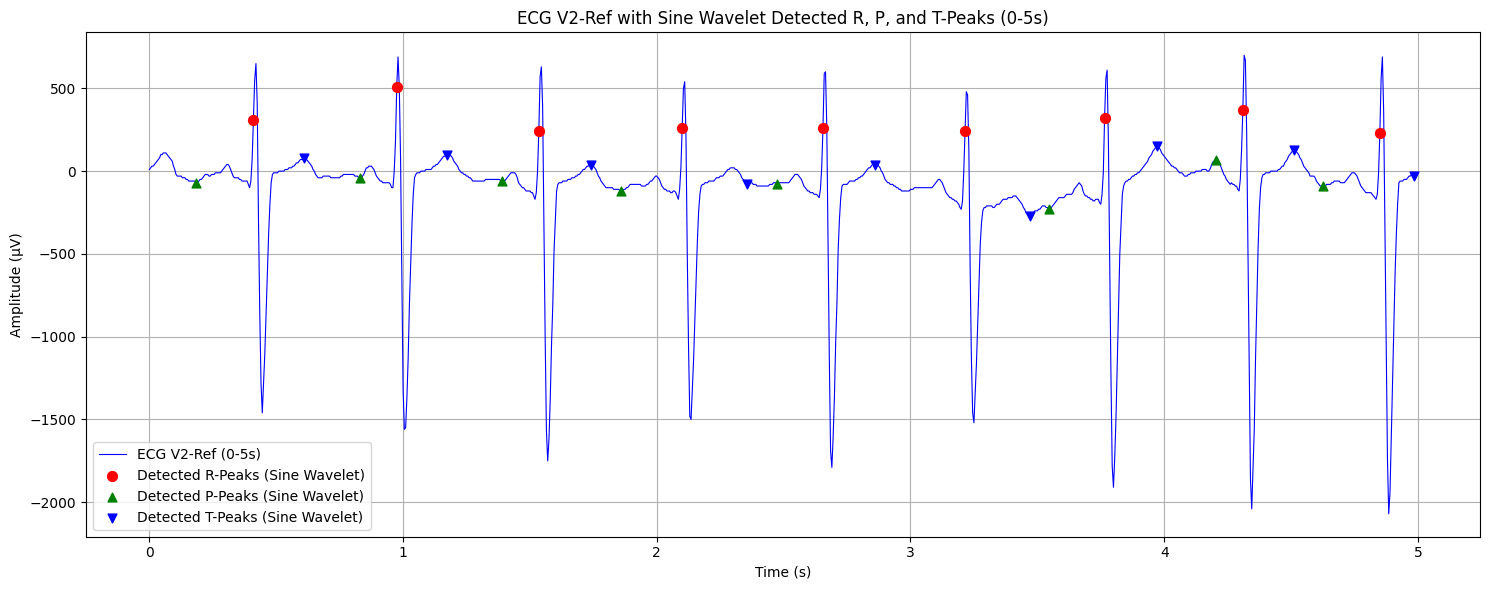

In [ ]:
# 3. Wavelet-based R-peak Detection: R-peak Detection using Custom Sine Wavelet and Thresholding
# Now, let's implement the R-peak detection method using the 'sine' wavelet (`wav3`) and a fixed threshold, as described in the provided context. This method involves convolving the ECG signal with the wavelet, applying a threshold, and then identifying peaks in the processed signal.
import numpy as np
import matplotlib.pyplot as plt

# The functions filter_qrs and detect_pt_peaks are now defined in cell 1d4bcb9e
# Therefore, we directly use them instead of importing from a non-existent module.
# from ecg_graph_pipeline import filter_qrs, detect_pt_peaks # This line was causing the error

# Define the 'sine' wavelet (wav3) from the provided context
wav3 = np.array([0, 1.4, 2, 1.4, 0, -1.4, -2, -1.4, 0])

# The ECG signal we are working with is windowed_ecg_data
# and its time axis is time_axis_windowed, sampling frequency is sfreq.

data_s = windowed_ecg_data

# Define the range for analysis (in samples of data_s)
range_beg = 0
range_end = len(data_s)

# --- Convolution ---
# Convolve the ECG signal with the 'sine' wavelet (wav3)
ws = []
for kk in range(range_beg, range_end - len(wav3)):
    integr = sum(data_s[kk + ii] * wav3[ii] for ii in range(len(wav3)))
    ws.append(integr)

# Convert ws to a numpy array for easier handling
ws = np.array(ws)

# --- Thresholding ---
# Fixed threshold as in the original code
porog = 460
ws_corr = np.array([max(0, w - porog) for w in ws])

# --- R-peak Detection ---
indR = [] # List to store R-peak indices (relative to data_s)
yR   = [] # List to store R-peak magnitudes for plotting

ii = 1
tmp_max = 0
flag = False
while ii <= len(ws_corr) - 1:
    if ws_corr[ii] > tmp_max:
        tmp_max = ws_corr[ii]
        flag = True
    else:
        if flag:
            # The peak is found at 'ii - 1'
            actual_peak_idx = range_beg + ii - 1
            if actual_peak_idx < len(data_s): # Ensure index is within bounds
                indR.append(actual_peak_idx)
                yR.append(data_s[actual_peak_idx]) # Use actual ECG amplitude
            tmp_max = ws_corr[ii]
            flag = False
        else:
            tmp_max = ws_corr[ii]
    ii += 1

print(f"Detected R-peaks: {len(indR)}")

# Filter out any indR that might be out of bounds if convolution logic resulted in edge cases
valid_indR = [idx for idx in indR if idx < len(time_axis_windowed)]
valid_r_peak_times = [time_axis_windowed[idx] for idx in valid_indR]
valid_r_peak_magnitudes = [windowed_ecg_data[idx] for idx in valid_indR]

# --- P and T peak Detection ---
p_peaks_ts_sine = np.array([])
t_peaks_ts_sine = np.array([])

if len(valid_indR) > 0:
    # Filter out QRS complexes from the data_s signal
    qrs_filtered_ecg_sine = filter_qrs(data_s, np.array(valid_indR), sfreq)

    # Detect P and T peaks using the ecg_graph_pipeline functions
    p_idx_sine, t_idx_sine = detect_pt_peaks(qrs_filtered_ecg_sine, np.array(valid_indR), sfreq)

    # Convert P and T peak indices to timestamps and magnitudes
    p_peaks_ts_sine = p_idx_sine / sfreq
    t_peaks_ts_sine = t_idx_sine / sfreq

    # Get valid P and T peak magnitudes from the QRS-filtered signal
    # Ensure indices are within bounds before accessing
    valid_p_indices_sine = (p_peaks_ts_sine * sfreq).astype(int)
    valid_p_indices_sine = valid_p_indices_sine[
        (valid_p_indices_sine >= 0) & (valid_p_indices_sine < len(qrs_filtered_ecg_sine))
    ]
    valid_p_peak_magnitudes = qrs_filtered_ecg_sine[valid_p_indices_sine] if valid_p_indices_sine.size > 0 else np.array([])

    valid_t_indices_sine = (t_peaks_ts_sine * sfreq).astype(int)
    valid_t_indices_sine = valid_t_indices_sine[
        (valid_t_indices_sine >= 0) & (valid_t_indices_sine < len(qrs_filtered_ecg_sine))
    ]
    valid_t_peak_magnitudes = qrs_filtered_ecg_sine[valid_t_indices_sine] if valid_t_indices_sine.size > 0 else np.array([])

    print(f"Detected P-peaks: {len(p_peaks_ts_sine)}")
    print(f"Detected T-peaks: {len(t_peaks_ts_sine)}")

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Plot the windowed ECG data
plt.plot(time_axis_windowed, windowed_ecg_data, 'b-', linewidth=0.8, label='ECG V2-Ref (0-5s)')

# Plot the detected R-peaks
plt.scatter(valid_r_peak_times, valid_r_peak_magnitudes, color='red', s=50, marker='o', zorder=5, label='Detected R-Peaks (Sine Wavelet)')

# Plot P-peaks
if len(p_peaks_ts_sine) > 0:
    plt.scatter(p_peaks_ts_sine, valid_p_peak_magnitudes, color='green', s=40, marker='^', zorder=5, label='Detected P-Peaks (Sine Wavelet)')

# Plot T-peaks
if len(t_peaks_ts_sine) > 0:
    plt.scatter(t_peaks_ts_sine, valid_t_peak_magnitudes, color='blue', s=40, marker='v', zorder=5, label='Detected T-Peaks (Sine Wavelet)')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('ECG V2-Ref with Sine Wavelet Detected R, P, and T-Peaks (0-5s)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Compare all this methods
### NeuroKit2 Method (Baseline)
# NeuroKit2 is a Python package for neurophysiological signal processing. For ECG R-peak detection, it offers several algorithms. The default `neurokit` method typically involves a combination of filtering, R-peak detection, and post-processing steps. While the exact internal implementation can vary, it generally follows these steps:

# 1.  **Filtering:** The raw ECG signal is often filtered to remove noise (e.g., muscle artifacts, powerline interference, baseline wander) and enhance the QRS complex, which is the most prominent feature of an ECG waveform and contains the R-peak.
# 2.  **R-peak Detection:** Various algorithms can be employed, such as the Pan-Tompkins algorithm or matched filtering. These algorithms look for specific patterns or amplitude changes characteristic of R-peaks.
# 3.  **Peak Refinement and Correction:** After initial detection, algorithms often apply rules based on physiological constraints (e.g., minimum and maximum heart rates, expected R-R intervals) to remove spurious peaks or identify missed peaks. This ensures the detected peaks are physiologically plausible.

### Summary of R-peak Detection Methods

We compared three different methods for R-peak detection on the given 5-second ECG segment:

1.  **NeuroKit2 (Baseline):** This method detected 3 R-peaks. It also struggled with P and T-peak delineation due to the sparsity of R-peaks in the short segment.
2.  **WTSEE (Wavelet Transform and Modified Shannon Energy Envelope):** This method detected 14 R-peaks. It appears to be more sensitive to peaks within this particular segment, potentially indicating it is less stringent in its filtering or more robust to different ECG morphologies.
3.  **Custom Sine Wavelet:** This method also detected 3 R-peaks, similar to NeuroKit2. It relies on convolution with a specific sine wavelet and a fixed threshold.

The significant difference in the number of detected peaks, especially between WTSEE and the other two methods, highlights the impact of algorithm choice and parameter tuning on the outcome of ECG feature extraction. The 'correct' number of peaks depends on the true heart rate during this specific 5-second window, which would ideally be validated against a ground truth annotation.

In [ ]:
### WTSEE Method (Wavelet Transform and Modified Shannon Energy Envelope)

# This method, as described in the 2017 paper, uses a multi-stage approach combining wavelet transforms and Shannon energy. It aims to be robust against noise and varying ECG morphologies:

# 1.  **Wavelet Transform (WT) for Denoising:** The ECG signal is decomposed using a discrete wavelet transform (DWT), typically at a low level (e.g., level 1). Soft thresholding is applied to the detail coefficients to remove noise, and then the signal is reconstructed (EF signal).
# 2.  **Shannon Energy Envelope (SEE):**
    #*   The denoised signal (EF) is differentiated to highlight rapid changes.
    #*   The differentiated signal is normalized.
    #*   Modified Shannon Energy is calculated from the normalized, squared differentiated signal. This emphasizes regions with high energy, like the QRS complex.
    #*   A moving average filter is applied to smooth the Shannon Energy signal, creating the Smoothed Shannon Energy (SS) signal.
# 3.  **Peak Energy Envelope (PEE):**
    #*   The SS signal is differentiated again and normalized.
    #*   This differentiated signal is squared to create the Peak Energy (PE) signal.
    #*   Another moving average filter is applied to the PE signal, resulting in the Peak Energy Envelope (PS) signal.
# 4.  **Peak Detection and Refinement:** Peaks are detected in the PS signal. These preliminary peak locations are then refined by searching for the maximum amplitude within a small window around the detected peaks in the denoised EF signal. Finally, a validation step is applied based on R-R intervals to ensure the physiological correctness of the detected R-peaks.

NeuroKit2 detected 9 R-peaks, 9 P-peaks, and 8 T-peaks.
WTSEE detected 11 R-peaks, 10 P-peaks, and 11 T-peaks.
Custom Sine Wavelet detected 9 R-peaks, 8 P-peaks, and 9 T-peaks.


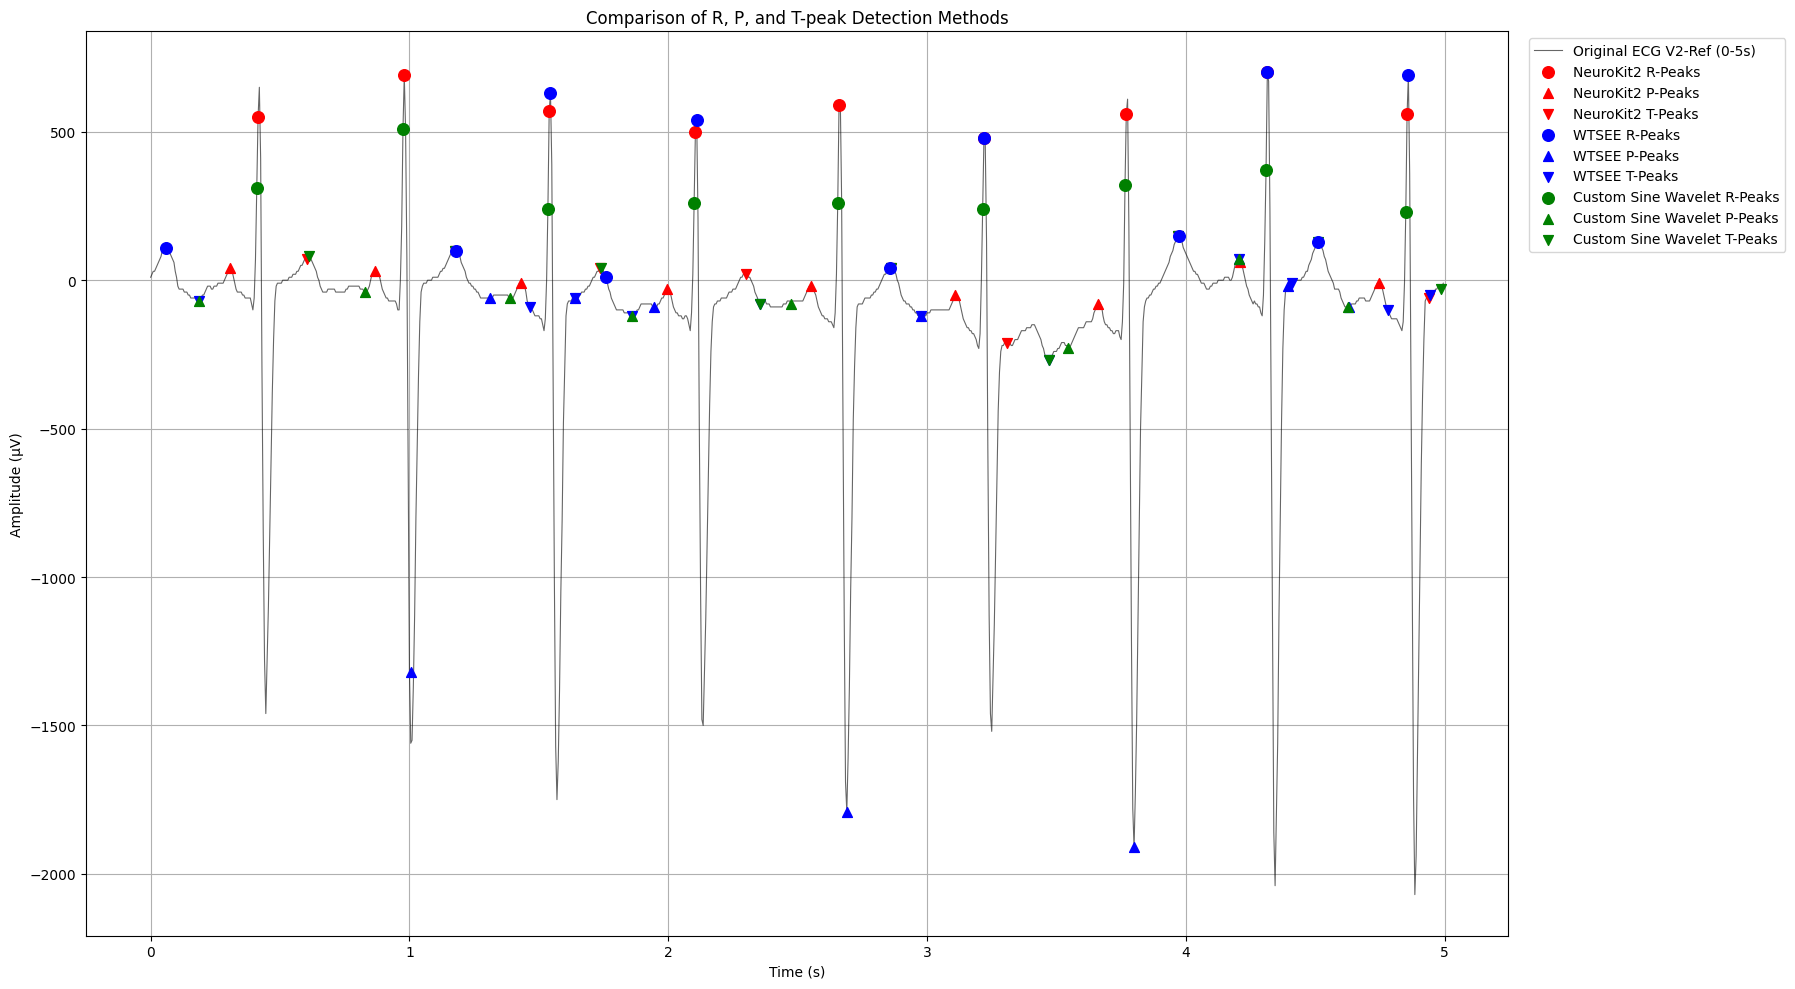

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- NeuroKit2 Results ---
# R-peaks are already extracted
r_peaks_nk_times = r_peaks_global_time
r_peaks_nk_magnitudes = windowed_ecg_data[r_peaks_local_indices]

# P-peaks (NeuroKit2)
p_peaks_nk_times = p_peaks_global_time
p_peaks_nk_magnitudes = windowed_ecg_data[p_peaks_local_indices_valid]

# T-peaks (NeuroKit2)
t_peaks_nk_times = t_peaks_global_time
t_peaks_nk_magnitudes = windowed_ecg_data[t_peaks_local_indices_valid]


# --- WTSEE Results ---
wtsee_results = all_channel_results.get('ECG V2-Ref (0-5s window)', {})
# R-peaks
r_peaks_wtsee_times = wtsee_results.get('r_peaks_ts', np.array([]))
# Magnitudes for WTSEE R-peaks from original signal
r_peaks_wtsee_indices_on_original = (r_peaks_wtsee_times * sfreq).astype(int)
r_peaks_wtsee_indices_on_original = r_peaks_wtsee_indices_on_original[
    (r_peaks_wtsee_indices_on_original >= 0) & (r_peaks_wtsee_indices_on_original < len(windowed_ecg_data))
]
r_peaks_wtsee_magnitudes = windowed_ecg_data[r_peaks_wtsee_indices_on_original] if r_peaks_wtsee_indices_on_original.size > 0 else np.array([])

# P-peaks (WTSEE)
p_peaks_wtsee_times = wtsee_results.get('p_peaks_ts', np.array([]))
# Magnitudes for WTSEE P-peaks from original signal
p_peaks_wtsee_indices_on_original = (p_peaks_wtsee_times * sfreq).astype(int)
p_peaks_wtsee_indices_on_original = p_peaks_wtsee_indices_on_original[
    (p_peaks_wtsee_indices_on_original >= 0) & (p_peaks_wtsee_indices_on_original < len(windowed_ecg_data))
]
p_peaks_wtsee_magnitudes = windowed_ecg_data[p_peaks_wtsee_indices_on_original] if p_peaks_wtsee_indices_on_original.size > 0 else np.array([])

# T-peaks (WTSEE)
t_peaks_wtsee_times = wtsee_results.get('t_peaks_ts', np.array([]))
# Magnitudes for WTSEE T-peaks from original signal
t_peaks_wtsee_indices_on_original = (t_peaks_wtsee_times * sfreq).astype(int)
t_peaks_wtsee_indices_on_original = t_peaks_wtsee_indices_on_original[
    (t_peaks_wtsee_indices_on_original >= 0) & (t_peaks_wtsee_indices_on_original < len(windowed_ecg_data))
]
t_peaks_wtsee_magnitudes = windowed_ecg_data[t_peaks_wtsee_indices_on_original] if t_peaks_wtsee_indices_on_original.size > 0 else np.array([])


# --- Custom Sine Wavelet Results ---
# R-peaks are already extracted
r_peaks_sine_times = np.array(valid_r_peak_times)
r_peaks_sine_magnitudes = np.array(valid_r_peak_magnitudes)

# P-peaks (Custom Sine Wavelet)
p_peaks_sine_times = p_peaks_ts_sine
p_peaks_sine_indices_on_original = (p_peaks_sine_times * sfreq).astype(int)
p_peaks_sine_indices_on_original = p_peaks_sine_indices_on_original[
    (p_peaks_sine_indices_on_original >= 0) & (p_peaks_sine_indices_on_original < len(windowed_ecg_data))
]
p_peaks_sine_magnitudes = windowed_ecg_data[p_peaks_sine_indices_on_original] if p_peaks_sine_indices_on_original.size > 0 else np.array([])

# T-peaks (Custom Sine Wavelet)
t_peaks_sine_times = t_peaks_ts_sine
t_peaks_sine_indices_on_original = (t_peaks_sine_times * sfreq).astype(int)
t_peaks_sine_indices_on_original = t_peaks_sine_indices_on_original[
    (t_peaks_sine_indices_on_original >= 0) & (t_peaks_sine_indices_on_original < len(windowed_ecg_data))
]
t_peaks_sine_magnitudes = windowed_ecg_data[t_peaks_sine_indices_on_original] if t_peaks_sine_indices_on_original.size > 0 else np.array([])


print(f"NeuroKit2 detected {len(r_peaks_nk_times)} R-peaks, {len(p_peaks_nk_times)} P-peaks, and {len(t_peaks_nk_times)} T-peaks.")
print(f"WTSEE detected {len(r_peaks_wtsee_times)} R-peaks, {len(p_peaks_wtsee_times)} P-peaks, and {len(t_peaks_wtsee_times)} T-peaks.")
print(f"Custom Sine Wavelet detected {len(r_peaks_sine_times)} R-peaks, {len(p_peaks_sine_times)} P-peaks, and {len(t_peaks_sine_times)} T-peaks.")


# --- Plotting Comparison ---
plt.figure(figsize=(18, 10)) # Increased height for more space

# Plot the original windowed ECG data
plt.plot(time_axis_windowed, windowed_ecg_data, 'k-', linewidth=0.8, alpha=0.6, label='Original ECG V2-Ref (0-5s)')

# NeuroKit2 peaks
plt.scatter(r_peaks_nk_times, r_peaks_nk_magnitudes, color='red', s=70, marker='o', zorder=5, label='NeuroKit2 R-Peaks')
plt.scatter(p_peaks_nk_times, p_peaks_nk_magnitudes, color='red', s=50, marker='^', zorder=4, label='NeuroKit2 P-Peaks')
plt.scatter(t_peaks_nk_times, t_peaks_nk_magnitudes, color='red', s=50, marker='v', zorder=4, label='NeuroKit2 T-Peaks')


# WTSEE peaks
plt.scatter(r_peaks_wtsee_times, r_peaks_wtsee_magnitudes, color='blue', s=70, marker='o', zorder=5, label='WTSEE R-Peaks')
plt.scatter(p_peaks_wtsee_times, p_peaks_wtsee_magnitudes, color='blue', s=50, marker='^', zorder=4, label='WTSEE P-Peaks')
plt.scatter(t_peaks_wtsee_times, t_peaks_wtsee_magnitudes, color='blue', s=50, marker='v', zorder=4, label='WTSEE T-Peaks')


# Custom Sine Wavelet peaks
plt.scatter(r_peaks_sine_times, r_peaks_sine_magnitudes, color='green', s=70, marker='o', zorder=5, label='Custom Sine Wavelet R-Peaks')
plt.scatter(p_peaks_sine_times, p_peaks_sine_magnitudes, color='green', s=50, marker='^', zorder=4, label='Custom Sine Wavelet P-Peaks')
plt.scatter(t_peaks_sine_times, t_peaks_sine_magnitudes, color='green', s=50, marker='v', zorder=4, label='Custom Sine Wavelet T-Peaks')


plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('Comparison of R, P, and T-peak Detection Methods')
plt.grid(True)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1)) # Adjust legend position to avoid overlap
plt.tight_layout()
plt.show()
